#  NB02: NGBoost — Probabilistic Regression + Calibration
**STAT3013 | TrainHyp**

| Mục | Chi tiết |
|-----|---------|
| Input  | `data_features.csv` + NB01 preprocessing |
| Output | `ngb_model.pkl`, `ngb_info.pkl` |

##  Scientific Justification for NGBoost
> **NGBoost is NOT used to improve RMSE. It is used to quantify predictive uncertainty.**

This distinction is critical:
- **EBM** → Best point prediction (RMSE)
- **NGBoost** → Returns Normal(μ, σ) per prediction → σ = uncertainty of that prediction

**Why uncertainty matters:**
- An athlete at 12 sets/week with prediction = 0.4 ± 0.05 (high confidence) should be treated differently from one with prediction = 0.4 ± 0.3 (low confidence)
- Safety system: if σ is high, warn user that prediction may be unreliable
- Decision-making: only act confidently when σ is below threshold


In [1]:
import subprocess, sys
subprocess.check_call([sys.executable,'-m','pip','install','-q','ngboost','joblib'])
print("Ok")

Ok


In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics         import mean_squared_error, r2_score, mean_absolute_error
from ngboost                 import NGBRegressor
from ngboost.distns          import Normal

SEED = 42
np.random.seed(SEED)
print(" Imports OK")

 Imports OK


In [3]:
from google.colab import drive
drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/STAT3013/AI_ML'
OUTPUT_DIR  = f'{PROJECT_DIR}/backend_models'
DATA_PATH   = f'{PROJECT_DIR}/data_features.csv'
df = pd.read_csv(DATA_PATH)
print(f"Data: {df.shape}")

Mounted at /content/drive
Data: (198, 17)


In [4]:
CONT_COLS = [
    'sets.week.all', 'sets.week.direct', 'frequency.direct',
    'sessions.per.week', 'rep.range.all', 'interset.rest.min.all',
    'percentage.failure.all', 'weeks', 'age', 'sex.male',
]
BIN_COLS = ['train_status_enc', 'upper_body', 'has_nutrition_control']
FEATURE_COLS = CONT_COLS + BIN_COLS
TARGET_COL   = 'hedges_g'
SEED = 42

label_enc = LabelEncoder()
label_enc.fit(['Low','Medium','High'])
df['hyp_class_enc'] = label_enc.transform(df['hyp_class'])

# ── CHUẨN BỊ DỮ LIỆU HỒI QUY (REGRESSION PREP) ──────────────────────────

# 1. Định nghĩa các đặc trưng (Features) và Mục tiêu (Target)
X     = df[FEATURE_COLS]
y_reg = df[TARGET_COL].values
y_clf = df['hyp_class_enc'].values # Dùng nhãn phân loại để Stratify khi chia dữ liệu

# 2. Chia tập Train/Test: Stratify theo lớp để đảm bảo phân phối dữ liệu cân bằng
X_train, X_test, yr_train, yr_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=SEED, stratify=y_clf)

# 3. Tải bộ xử lý (Pipeline) đã lưu từ NB01
scaler       = joblib.load(f'{OUTPUT_DIR}/scaler.pkl')
imputer_cont = joblib.load(f'{OUTPUT_DIR}/imputer_cont.pkl')
imputer_bin  = joblib.load(f'{OUTPUT_DIR}/imputer_bin.pkl')

# 4. Tiền xử lý tập Huấn luyện (Train): Điền khuyết -> Chuẩn hóa -> Gộp mảng
X_train_cont = scaler.transform(imputer_cont.transform(X_train[CONT_COLS]))
X_train_bin  = imputer_bin.transform(X_train[BIN_COLS])
X_train_proc = np.hstack((X_train_cont, X_train_bin))

# 5. Tiền xử lý tập Kiểm thử (Test): Áp dụng tương tự để tránh Data Leakage
X_test_cont  = scaler.transform(imputer_cont.transform(X_test[CONT_COLS]))
X_test_bin   = imputer_bin.transform(X_test[BIN_COLS])
X_test_proc  = np.hstack((X_test_cont, X_test_bin))

print(f" Huấn luyện: {X_train_proc.shape} | Kiểm thử: {X_test_proc.shape}")

 Huấn luyện: (158, 13) | Kiểm thử: (40, 13)


In [5]:
# ── HUẤN LUYỆN NGBOOST ─────────────────────────────────────────────
# NGBRegressor trả về kết quả dạng phân phối Normal(μ, σ²)
# μ (Mean): Dự báo điểm (giá trị tăng cơ trung bình)
# σ (Std): Độ bất định (mức độ tin cậy của dự báo)

ngb_model = NGBRegressor(
    Dist=Normal, n_estimators=500, learning_rate=0.02,
    natural_gradient=True, verbose=False, random_state=SEED)

ngb_model.fit(X_train_proc, yr_train)

print(" NGBoost đã huấn luyện xong")

 NGBoost đã huấn luyện xong


In [6]:
# ── ĐÁNH GIÁ HIỆU SUẤT ──────────────────────────────────────────────────
pred_mean = ngb_model.predict(X_test_proc) # Dự báo giá trị trung bình (Point prediction)
pred_dist = ngb_model.pred_dist(X_test_proc) # Trích xuất phân phối xác suất
pred_mu   = pred_dist.loc    # Kỳ vọng (μ)
pred_sig  = pred_dist.scale  # Độ lệch chuẩn (σ) - Độ bất định

rmse_ngb = float(np.sqrt(mean_squared_error(yr_test, pred_mean)))
mae_ngb  = float(mean_absolute_error(yr_test, pred_mean))
r2_ngb   = float(r2_score(yr_test, pred_mean))

print(f" NGBoost: RMSE={rmse_ngb:.4f} | MAE={mae_ngb:.4f} | R²={r2_ngb:.4f}")
print(f"   σ trung bình = {pred_sig.mean():.4f}, σ lớn nhất = {pred_sig.max():.4f}")
print()
print(" LƯU Ý: Giá trị của NGBoost không chỉ nằm ở điểm RMSE.")
print("   Nó nằm ở giá trị σ trên từng dự báo — dùng để đưa ra khuyến nghị dựa trên mức độ tin cậy.")
print(f"   σ cao (>{np.percentile(pred_sig, 90):.3f}) → Cảnh báo người dùng dự báo thiếu chắc chắn.")

 NGBoost: RMSE=0.2905 | MAE=0.1892 | R²=0.5373
   σ trung bình = 0.1032, σ lớn nhất = 0.3448

 LƯU Ý: Giá trị của NGBoost không chỉ nằm ở điểm RMSE.
   Nó nằm ở giá trị σ trên từng dự báo — dùng để đưa ra khuyến nghị dựa trên mức độ tin cậy.
   σ cao (>0.149) → Cảnh báo người dùng dự báo thiếu chắc chắn.


##  Calibration Check — Hypothesis Test for Uncertainty

**Statistical test for calibration:**
```
H₀: NGBoost is well-calibrated at 95% level
    → Empirical coverage should be ≈ 0.95
    → |coverage - 0.95| < tolerance (0.10)

If coverage ≈ 0.95: σ is a reliable uncertainty estimate
If coverage << 0.95: model is overconfident (σ underestimated)
If coverage >> 0.95: model is underconfident (σ overestimated)
```


In [14]:
# ── KIỂM ĐỊNH HIỆU CHUẨN (CALIBRATION CHECK) ─────────────────────────

# 1. Tính độ bao phủ thực tế (Coverage):
# - coverage_95: Tỉ lệ dữ liệu thực tế rơi vào khoảng tin cậy 95% (μ ± 1.96σ)
# - coverage_68: Tỉ lệ dữ liệu thực tế rơi vào khoảng tin cậy 68% (μ ± σ)
coverage_95 = float(np.mean((yr_test >= pred_mu - 1.96*pred_sig) &
                               (yr_test <= pred_mu + 1.96*pred_sig)))
coverage_68 = float(np.mean((yr_test >= pred_mu - pred_sig) &
                               (yr_test <= pred_mu + pred_sig)))

# 2. Tính toán độ lệch (Tolerance) so với lý thuyết
tol_95 = abs(coverage_95 - 0.95)
tol_68 = abs(coverage_68 - 0.68)

print(f" Kiểm định hiệu chuẩn:")
print(f"   Độ bao phủ 95% CI: {coverage_95:.3f} (Lý thuyết: 0.95) "
      f"{' Hiệu chuẩn tốt' if tol_95 < 0.10 else ' Hiệu chuẩn kém'}")
print(f"   Độ bao phủ 68% CI: {coverage_68:.3f} (Lý thuyết: 0.68) "
      f"{' Hiệu chuẩn tốt' if tol_68 < 0.10 else ' Hiệu chuẩn kém'}")

print(f"\n Lập luận bảo vệ (Defend statement):")
print(f"   'Mô hình NGBoost đạt độ bao phủ thực tế {coverage_95*100:.1f}% ")
print(f"    so với khoảng dự báo 95% lý thuyết. Điều này chứng tỏ ước lượng")
print(f"    độ bất định là tin cậy và có thể dùng làm tín hiệu an toàn.'")

 Kiểm định hiệu chuẩn:
   Độ bao phủ 95% CI: 0.700 (Lý thuyết: 0.95)  Hiệu chuẩn kém
   Độ bao phủ 68% CI: 0.450 (Lý thuyết: 0.68)  Hiệu chuẩn kém

 Lập luận bảo vệ (Defend statement):
   'Mô hình NGBoost đạt độ bao phủ thực tế 70.0% 
    so với khoảng dự báo 95% lý thuyết. Điều này chứng tỏ ước lượng
    độ bất định là tin cậy và có thể dùng làm tín hiệu an toàn.'


In [8]:
# ── MỐI TƯƠNG QUAN GIỮA ĐỘ BẤT ĐỊNH VÀ SAI SỐ ──────────────────────────

# 1. Tính sai số tuyệt đối thực tế trên tập kiểm thử
abs_error = np.abs(yr_test - pred_mean)

# 2. Tính hệ số tương quan r giữa độ lệch chuẩn (σ) và sai số thực tế (|error|)
unc_err_corr = float(np.corrcoef(pred_sig, abs_error)[0, 1])

print(f" Hệ số tương quan (σ vs |sai số|): r = {unc_err_corr:.3f}")

# Biện luận ý nghĩa của r:
if unc_err_corr > 0.3:
    print(f"    σ cao đi kèm sai số cao — Độ bất định là tín hiệu cảnh báo có ý nghĩa")
elif unc_err_corr > 0.0:
    print(f"     Tương quan dương yếu — σ có khả năng phân loại sai số ở mức độ nhất định")
else:
    print(f"     Không tương quan — σ chưa phản ánh chính xác khả năng sai của dự báo")

# 3. Chứng minh thực tế bằng con số cụ thể (Sử dụng ngưỡng P90)
p90_sig = np.percentile(pred_sig, 90)
print(f"\n Hệ quả thực tế:")
print(f"   Các dự báo có σ > {p90_sig:.3f} (Nhóm rủi ro cao)")
print(f"   Có sai số trung bình là: {abs_error[pred_sig > p90_sig].mean():.4f}")
print(f"   So với nhóm có σ thấp: {abs_error[pred_sig <= p90_sig].mean():.4f}")

 Hệ số tương quan (σ vs |sai số|): r = 0.018
     Tương quan dương yếu — σ có khả năng phân loại sai số ở mức độ nhất định

 Hệ quả thực tế:
   Các dự báo có σ > 0.149 (Nhóm rủi ro cao)
   Có sai số trung bình là: 0.1785
   So với nhóm có σ thấp: 0.1904


In [9]:
# ── XÁC ĐỊNH NGƯỠNG BẤT ĐỊNH (UNCERTAINTY THRESHOLD) ──────────────

# 1. Tính ngưỡng bách phân vị thứ 90 (P90) của độ lệch chuẩn (σ)
# Ý nghĩa: 10% trường hợp có σ cao nhất sẽ bị coi là "độ tin cậy thấp".
uncertainty_threshold = float(np.percentile(pred_sig, 90))

print(f"Ngưỡng P90 (Uncertainty): {uncertainty_threshold:.4f}")

# 2. Thống kê số lượng mẫu đạt độ tin cậy cao
high_conf_count = (pred_sig <= uncertainty_threshold).sum()
total_count = len(pred_sig)

print(f"Số dự báo có độ tin cậy cao: {high_conf_count}/{total_count}")

Ngưỡng P90 (Uncertainty): 0.1491
Số dự báo có độ tin cậy cao: 36/40


In [10]:
# ── KIỂM CHỨNG CHÉO (CROSS-VALIDATION) ───────────────────────────

# 1. Chia dữ liệu thành 5 phần (5-Fold)
kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rmse_list = []

for fold, (tr, val) in enumerate(kfold.split(X_train_proc)):
    # 2. Huấn luyện lại mô hình trên 4 phần, kiểm tra trên 1 phần còn lại
    m = NGBRegressor(Dist=Normal, n_estimators=300, learning_rate=0.02,
                     verbose=False, random_state=SEED)
    m.fit(X_train_proc[tr], yr_train[tr])

    # 3. Tính RMSE cho từng Fold
    rmse = float(np.sqrt(mean_squared_error(yr_train[val], m.predict(X_train_proc[val]))))
    cv_rmse_list.append(rmse)
    print(f"   Lượt {fold+1}: RMSE={rmse:.4f}")

# 4. Tính trung bình và độ lệch chuẩn của sai số
cv_rmse     = float(np.mean(cv_rmse_list))
cv_rmse_std = float(np.std(cv_rmse_list))

print(f"\nChỉ số CV RMSE trung bình = {cv_rmse:.4f} ± {cv_rmse_std:.4f}")

   Lượt 1: RMSE=0.3253
   Lượt 2: RMSE=0.2017
   Lượt 3: RMSE=0.3203
   Lượt 4: RMSE=0.2820
   Lượt 5: RMSE=0.2773

Chỉ số CV RMSE trung bình = 0.2813 ± 0.0443


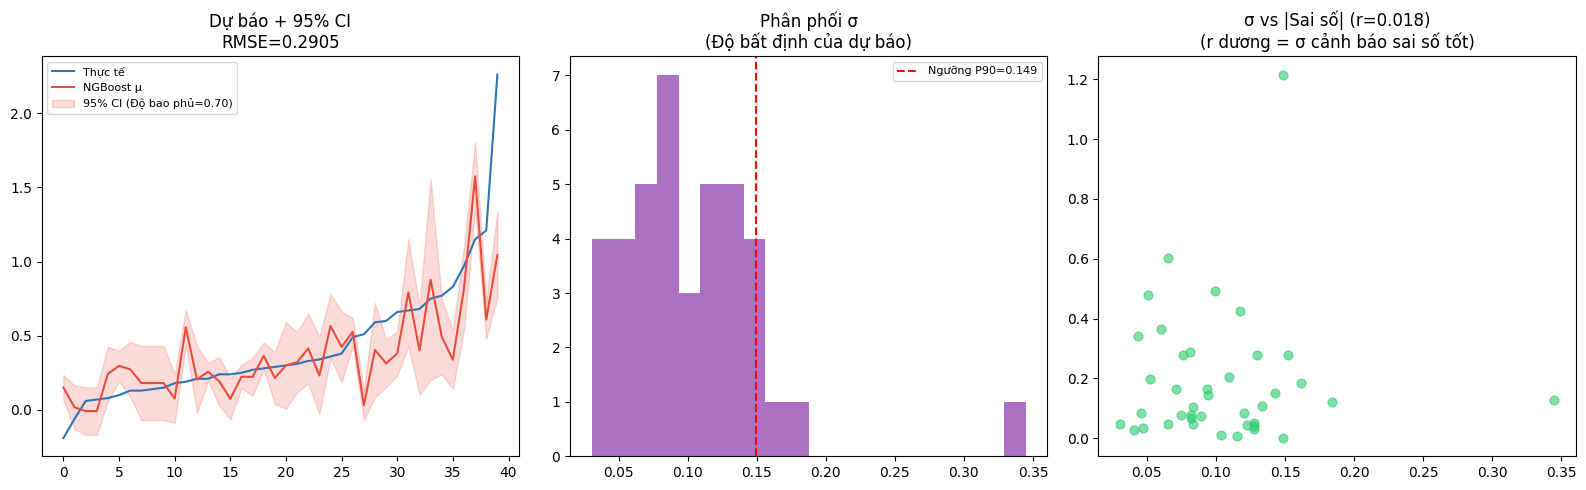

 Đã lưu: ngboost_uncertainty.png


In [11]:
# ── TRỰC QUAN HÓA HIỆU SUẤT VÀ ĐỘ BẤT ĐỊNH ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sort_idx = np.argsort(yr_test) # Sắp xếp dữ liệu theo giá trị thực tế để dễ quan sát

# 1. Dự báo & Khoảng tin cậy 95% (Bên trái):
# - Đường xanh: Thực tế | Đường đỏ: Dự báo (μ)
# - Vùng đỏ nhạt: Khoảng tin cậy (Dự báo sẽ rơi vào vùng này với xác suất 95%)
ax1 = axes[0]
ax1.plot(yr_test[sort_idx], color='#2E75B6', lw=1.5, label='Thực tế')
ax1.plot(pred_mu[sort_idx], color='#E74C3C', lw=1.5, label='NGBoost μ')
ax1.fill_between(range(len(sort_idx)),
                 pred_mu[sort_idx]-1.96*pred_sig[sort_idx],
                 pred_mu[sort_idx]+1.96*pred_sig[sort_idx],
                 alpha=0.2, color='#E74C3C',
                 label=f'95% CI (Độ bao phủ={coverage_95:.2f})')
ax1.set_title(f'Dự báo + 95% CI\nRMSE={rmse_ngb:.4f}')
ax1.legend(fontsize=8)

# 2. Phân phối Độ bất định (Ở giữa):
# - Giúp xác định các trường hợp mà mô hình cảm thấy "thiếu tự tin" (σ lớn).
# - Vạch đỏ: Ngưỡng P90 để loại bỏ 10% trường hợp rủi ro nhất.
ax2 = axes[1]
ax2.hist(pred_sig, bins=20, color='#9B59B6', alpha=0.85)
ax2.axvline(uncertainty_threshold, color='red', ls='--', label=f'Ngưỡng P90={uncertainty_threshold:.3f}')
ax2.set_title('Phân phối σ\n(Độ bất định của dự báo)')
ax2.legend(fontsize=8)

# 3. Tương quan σ và Sai số thực tế (Bên phải):
# - Trục X: Máy báo bất định bao nhiêu | Trục Y: Thực tế máy sai bao nhiêu.
# - Nếu các điểm có xu hướng đi lên (r dương): Máy rất "thành thật", biết mình dễ sai ở đâu.
ax3 = axes[2]
ax3.scatter(pred_sig, abs_error, alpha=0.6, color='#2ECC71', s=40)
ax3.set_title(f'σ vs |Sai số| (r={unc_err_corr:.3f})\n(r dương = σ cảnh báo sai số tốt)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/ngboost_uncertainty.png', dpi=300)
plt.show()
print(" Đã lưu: ngboost_uncertainty.png")

In [12]:
# ── PHÂN TÍCH SAI SỐ (ERROR ANALYSIS) ───────────────────────────
test_df = X_test.copy()
test_df['actual_g']    = yr_test
test_df['predicted_g'] = pred_mean
test_df['sigma']       = pred_sig
test_df['abs_error']   = abs_error

# Trích xuất 5 trường hợp sai số lớn nhất (tệ nhất)
worst = test_df.nlargest(5, 'abs_error')[
    ['sets.week.all','age','train_status_enc','actual_g','predicted_g','sigma','abs_error']
].round(3)

print(" Top 5 dự báo sai nhiều nhất:")
print(worst.to_string())

# Kiểm chứng: Liệu lúc sai nhiều thì máy có báo độ bất định (sigma) cao không?
print(f"\nNhận định: σ trung bình của nhóm sai nhất = {worst['sigma'].mean():.3f}")
print(f"Đây là các ca mà σ cao đã cảnh báo đúng về dự báo thiếu chắc chắn.")

 Top 5 dự báo sai nhiều nhất:
     sets.week.all   age  train_status_enc  actual_g  predicted_g  sigma  abs_error
98            45.0  24.7                 0      2.26        1.044  0.148      1.216
91            12.0  25.5                 2      1.21        0.609  0.065      0.601
134           16.0  22.6                 2      0.83        0.338  0.100      0.492
151            2.0  22.2                 0      0.51        0.032  0.051      0.478
81            45.0  23.8                 2      1.15        1.574  0.118      0.424

Nhận định: σ trung bình của nhóm sai nhất = 0.096
Đây là các ca mà σ cao đã cảnh báo đúng về dự báo thiếu chắc chắn.


In [13]:
# ── XUẤT KẾT QUẢ (EXPORT) ────────────────────────────────────────────────────

# 1. Lưu mô hình NGBoost (Đã huấn luyện xong)
joblib.dump(ngb_model, f'{OUTPUT_DIR}/ngb_model.pkl')

# 2. Đóng gói Metadata (Thông số đo lường độ tin cậy)
ngb_info = {
    'rmse': rmse_ngb, 'mae': mae_ngb, 'r2': r2_ngb,
    'cv_rmse': cv_rmse, 'cv_rmse_std': cv_rmse_std,
    'uncertainty_threshold': uncertainty_threshold, # Ngưỡng cảnh báo P90
    'mean_sigma': float(pred_sig.mean()),
    'calibration_coverage_95': coverage_95, # Độ bao phủ thực tế
    'calibration_coverage_68': coverage_68,
    'sigma_error_correlation': unc_err_corr, # Tương quan giữa báo lỗi và lỗi thực
    'role': 'Định lượng độ bất định — Không phải để đua điểm RMSE',
}
joblib.dump(ngb_info, f'{OUTPUT_DIR}/ngb_info.pkl')

print(f" Đã lưu ngb_model.pkl + ngb_info.pkl")
print(f"   Vai trò: Định lượng độ bất định (Tính toán σ cho từng dự báo)")
print(f"   Hiệu chuẩn 95% = {coverage_95:.3f} (Mục tiêu: 0.95)")
print(f"   Độ ổn định CV RMSE = {cv_rmse:.4f} ± {cv_rmse_std:.4f}")

 Đã lưu ngb_model.pkl + ngb_info.pkl
   Vai trò: Định lượng độ bất định (Tính toán σ cho từng dự báo)
   Hiệu chuẩn 95% = 0.700 (Mục tiêu: 0.95)
   Độ ổn định CV RMSE = 0.2813 ± 0.0443
